-----

------

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from scipy.stats import pointbiserialr

### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compra_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `edad` y `nivel_ingreso` requiere un cambio de tipo de datos de float64 a int64.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato
df['edad']=df['edad'].astype(int)

In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  int64  
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(3), int64(6), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
columnas_numericas=['edad','nivel_ingreso','visitas_mes','compras_mes','gasto_publicidad_dirigida','satisfaccion','ingreso_anual']
df[columnas_numericas].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.219667,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.149019,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23126.500000,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.500000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.000000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.000000,25.000000,8.000000,75.510000,5.000000,244.690000


### Diagnóstico inicial de variables numéricas

- No se detectan valores sentinels en ninguna de las variables numéricas. La cercanía entre media y mediana sugiere ausencia de sesgo marcado en la distribución, aunque se requieren visualizaciones adicionales para caracterizar la forma de cada variable con mayor precisión.
- Los rangos y valores máximos observados en el .describe() sugieren la presencia de valores extremos en todas las columnas excepto `satisfaccion`. Determinar si estos requieren tratamiento o deben retenerse queda como un paso pendiente para análisis posteriores.

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
print("Valores únicos en miembro_premium:", df['miembro_premium'].unique())
print("Valores únicos en abandono:", df['abandono'].unique())

print("Proporciones miembro_premium:")
print(df['miembro_premium'].value_counts(normalize=True))
print("\nProporciones abandono:")
print(df['abandono'].value_counts(normalize=True))

Valores únicos en miembro_premium: [0 1]
Valores únicos en abandono: [0 1]
Proporciones miembro_premium:
0    0.860733
1    0.139267
Name: miembro_premium, dtype: float64

Proporciones abandono:
0    0.849267
1    0.150733
Name: abandono, dtype: float64


### Diagnóstico inicial de variables binarias

- `miembro_premium` tiene dos valores unicos, confirma que es una columna binaria, con una distrubucion de 86% en 0 y 14% en 1.
- `abandono` tiene dos valores unicos, confirma que es una columna binaria, con una distrubucion de 85% en 0 y 15% en 1.

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
columnas_cat=['id_cliente','region','tipo_dispositivo']
df[columnas_cat].describe()

,id_cliente,region,tipo_dispositivo
count,15000,15000,15000
unique,15000,4,3
top,CL-112717,norte,móvil
freq,1,4395,9818


In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print("Distribución tipo_dispositivo:")
print(df['tipo_dispositivo'].value_counts())
print("Distribución region:")
print(df['region'].value_counts())

Distribución tipo_dispositivo:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64
Distribución region:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


### Diagnóstico inicial de variables categóricas

- La variable `tipo_dispositivo` comprende 3 categorías: móvil, escritorio y tablet. Móvil es la más representada, concentrando más del 65% de los registros. Escritorio le sigue con aproximadamente el 25%, mientras que tablet constituye menos del 10% del total.

- En cuanto a `region`, se identifican 4 valores únicos: norte, sur, este y oeste. Norte lidera con cerca del 30% de los registros, seguida por oeste y sur, ambas con distribuciones similares cercanas al 25% cada una. Finalmente, este representa alrededor del 20%.
- Por su parte, `id_cliente` presenta valores completamente únicos, ya que cada entrada corresponde a un identificador exclusivo de cliente.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

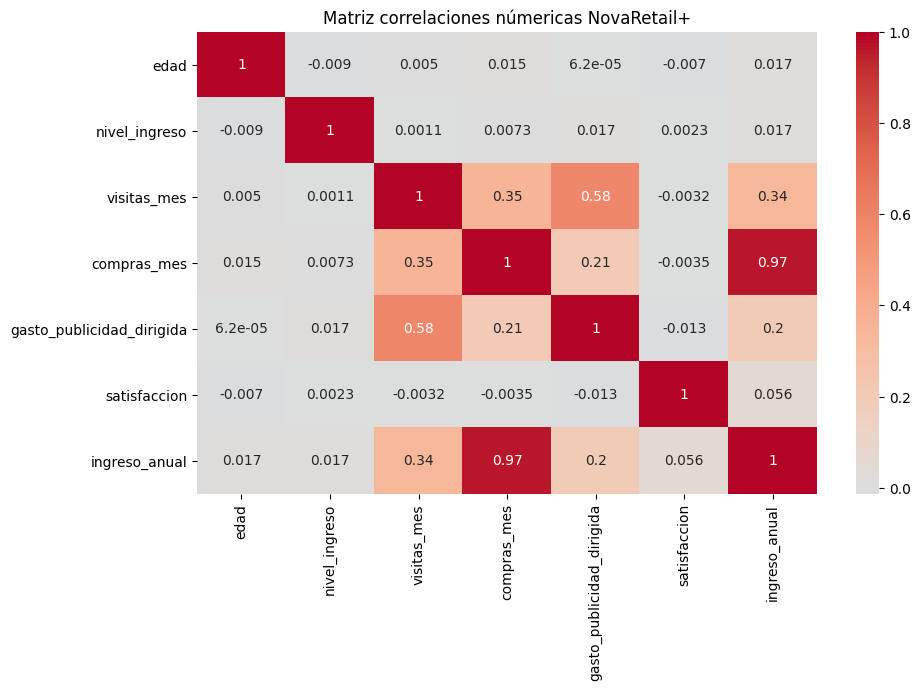

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
df_corr=df[['edad','nivel_ingreso','visitas_mes','compras_mes','gasto_publicidad_dirigida','satisfaccion','ingreso_anual']].corr()

plt.figure(figsize=(10,6))
sns.heatmap(df_corr,annot=True,cmap='coolwarm',center=0)
plt.title('Matriz correlaciones númericas NovaRetail+')
plt.show()

### Observaciones generales (Heatmap)  
- En términos generales, no se observan correlaciones negativas entre las variables numéricas. Se identifica una correlación moderada entre `visitas_mes` y `gasto_publicidad_dirigida`, lo que sugiere una relación positiva entre el volumen de visitas y la inversión en publicidad dirigida.
Adicionalmente, se evidenciaron cuatro correlaciones débiles: `entre visitas_mes` e `ingreso_anual`; entre `compra_mes` y `visitas_mes`; entre `compra_mes` y `gasto_publicidad_dirigida`; y entre `gasto_publicidad_dirigida` e `ingreso_anual`.
Es importante destacar que la existencia de correlación no implica causalidad. Por lo tanto, será necesario investigar con mayor detalle estas relaciones para entender qué las genera.

### Observaciones respecto a `ingreso_anual`  
- Presenta una correlación positiva muy fuerte de 0.97 con `compras_mes`. Es importante investigar si esta correlación representa colinealidad o una dependencia funcional entre ambas variables.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

No se recomienda realizar un scatterplot general de todas las correlaciones identificadas, principalmente porque la mayoría de las relaciones son muy débiles (menores a 0.20) o prácticamente nulas, lo que resultaría en visualizaciones con alto ruido y bajo valor interpretativo. Adicionar gráficos de dispersión para correlaciones cercanas a cero no aportaría insights significativos al análisis y diluiría la atención en relaciones que carecen de relevancia práctica.

### Scatterplot para pares clave

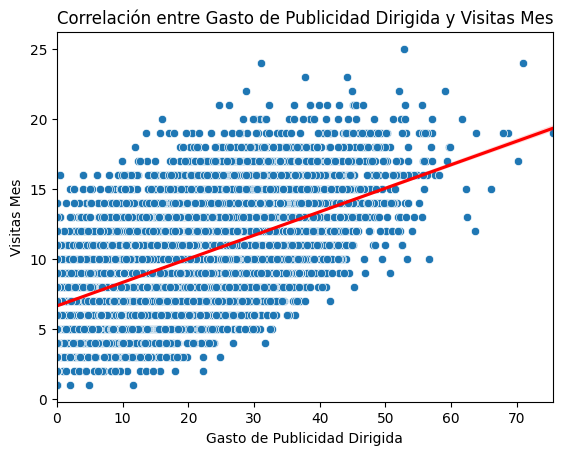

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=df, x='gasto_publicidad_dirigida',y='visitas_mes')
sns.regplot(data=df, x='gasto_publicidad_dirigida',y='visitas_mes',scatter=False,color='red')
plt.title('Correlación entre Gasto de Publicidad Dirigida y Visitas Mes')
plt.xlabel('Gasto de Publicidad Dirigida')
plt.ylabel('Visitas Mes')
plt.show()

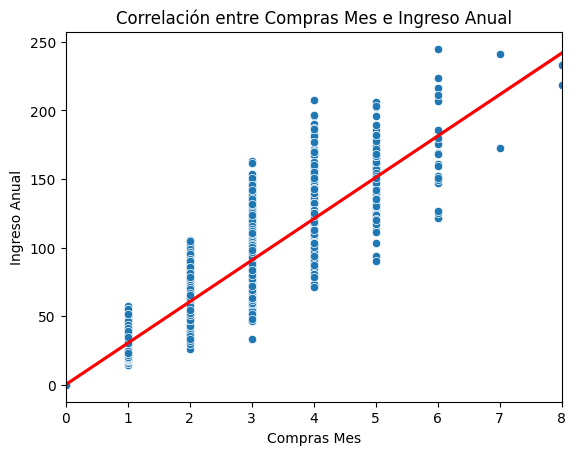

In [ ]:
sns.scatterplot(data=df, x='compras_mes',y='ingreso_anual')
sns.regplot(data=df, x='compras_mes',y='ingreso_anual',scatter=False,color='red')
plt.title('Correlación entre Compras Mes e Ingreso Anual')
plt.xlabel('Compras Mes')
plt.ylabel('Ingreso Anual')
plt.show()

### Observaciones iniciales (Scatterplot)

**`gasto_publicidad_dirigido` vs `visitas_mes`**
- **Dirección:** Positiva
- **Dispersión:** Media-alta. Los puntos se distribuyen ampliamente alrededor de la línea de tendencia, indicando variabilidad considerable en la relación.
- **Outliers:** Sí, presentes. Se observan clientes con alto gasto publicitario pero visitas moderadas, y algunos con bajo gasto pero visitas altas.
- **Colinealidad:** No representa problema significativo. Con una correlación de 0.58, el riesgo de multicolinealidad entre estas variables es bajo, aunque esto no implica independencia completa.

**`compras_mes` vs `ingreso_anual`**
- **Dirección:** Positiva
- **Dispersión:** Baja. Los puntos siguen un patrón casi lineal muy definido con mínima variabilidad alrededor de la línea.
- **Outliers:** Muy pocos. Apenas algunos puntos aislados fuera del patrón principal.
- **Colinealidad:** Alta. Sabiendo que `ingreso_anual` es el ingreso acumulado del cliente y `compras_mes` son las compras mensuales, la correlación casi perfecta (0.97) es lógica: clientes con mayor ingreso anual realizan más compras al mes de forma consistente. Esta relación es esperada y no representa un problema de colinealidad en sentido de error de medición, sino una dependencia funcional natural entre variables. Sin embargo, si se usan ambas en un modelo predictivo, una podría ser redundante.


## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:

# Calcular correlación entre variables relevantes
print(df['gasto_publicidad_dirigida'].corr(df['visitas_mes'],method='pearson'))
print(df['compras_mes'].corr(df['ingreso_anual'],method='pearson'))


0.5789472719412827
0.9671485435708564


In [ ]:

# Calcular correlación entre variables relevantes
print(df['gasto_publicidad_dirigida'].corr(df['visitas_mes'],method='spearman'))
print(df['compras_mes'].corr(df['ingreso_anual'],method='spearman'))


0.5592673242622609
0.967482492032673


### Observaciones de correlación

**`gasto_publicidad_dirigida` vs `visitas_mes`**
- **Magnitud:** Moderada (Pearson: 0.579 | Spearman: 0.559)
- **Dirección:** Positiva en ambos métodos
- **Interpretación:** Los coeficientes Pearson y Spearman son muy similares, lo que indica que la relación es lineal y consistente. No hay diferencia significativa entre las correlaciones, sugiriendo que no existen patrones no lineales fuertes.
- **Colinealidad:** No representa problema significativo. Con una correlación de 0.58, el riesgo de multicolinealidad es bajo, aunque esto no implica independencia completa.

**compras_mes vs ingreso_anual**
- **Magnitud:** Muy fuerte (Pearson: 0.967 | Spearman: 0.967)
- **Dirección:** Positiva en ambos métodos
- **Interpretación:** La correlación es prácticamente idéntica en ambos métodos (0.967), lo que confirma una relación lineal muy fuerte y consistente, no distorsionada por valores extremos. Esta estabilidad sugiere que ambas variables capturan información muy similar y se mueven de forma casi proporcional.
- **Colinealidad:** Sí existe. La correlación extremadamente alta sugiere que estas variables capturan información muy similar. Sin embargo, desde una perspectiva de negocio, compras_mes es el driver (generador) de ingreso_anual, por lo que retener ambas en modelos predictivos sería redundante.

### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes
pb,_=pointbiserialr(df['miembro_premium'],df['ingreso_anual'])
print('Correlación entre:miembro premium e ingreso anual')
print(f'punto biserial:{pb:.3f}')
pb,_=pointbiserialr(df['abandono'],df['ingreso_anual'])
print('Correlación entre:abandono e ingreso anual')
print(f'punto biserial:{pb:.3f}')

Correlación entre:miembro premium e ingreso anual
punto biserial:0.093
Correlación entre:abandono e ingreso anual
punto biserial:-0.003


### Observaciones Punto-biserial

**`miembro_premium` vs `ingreso_anual`**
- La asociación es positiva pero muy débil (0.093), lo que sugiere que el estatus premium tiene poca relación con el ingreso anual generado por el cliente.

**`abandono` vs `ingreso anual`**
- La asociación es prácticamente nula (-0.003), lo que sugiere que el abandono no tiene relación apreciable con el nivel de ingreso anual generado.

### V de Cramér

In [ ]:
# Función para calcular V de Cramér
def cramer_v(df,col1,col2):
    tabla=pd.crosstab(df[col1],df[col2])
    chi2,p_value,dof,expected=chi2_contingency(tabla)
    n=tabla.values.sum()
    v=np.sqrt(chi2/(n*(min(tabla.shape)-1)))
    return v

In [ ]:
# Aplicar V de Cramér en variables relevantes
coef_cramer=cramer_v(df,'region','tipo_dispositivo')

print('Correlación entre: region y tipo_dispositivo')
print(f'v de cramer:{coef_cramer:.3f}')


Correlación entre: region y tipo_dispositivo
v de cramer:0.012


**Observaciones V de Cramér**

- **Correlación:** Región vs Tipo de Dispositivo
- **Magnitud:** Prácticamente nula = 0.012
- **Interpretación:** Un valor de 0.012 indica una asociación prácticamente nula entre región y tipo de dispositivo, sin que esto permita afirmar independencia completa entre ambas variables.


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar

5) Implicación de negocio


---

### Hallazgo 1 — Gasto en publicidad dirigida y Visitas

**Evidencia visual:** scatterplot y heatmap  
**Evidencia numérica:** Pearson=0.58

**Interpretación**  
Se identifica una correlación positiva moderada entre el gasto en publicidad dirigida y el volumen de visitas mensuales, indicando que aumentos en inversión publicitaria tienden a asociarse con más tráfico al sitio. Sin embargo, la dispersión media-alta alrededor de la línea de tendencia sugiere que esta relación no es determinística: existe considerable variabilidad en cómo se convierte el gasto publicitario en visitas.

**No podemos afirmar**  
Que el gasto en publicidad dirigida causa directamente las visitas. La correlación observada no descarta que otras variables (estacionalidad, tipo de campaña, segmento de audiencia) influyan en ambas o que la efectividad publicitaria varíe significativamente entre clientes.

**Implicación de negocio**  
Optimizar el ROI publicitario requiere ir más allá del volumen de inversión. Algunos clientes generan alto tráfico con bajo gasto mientras otros invierten más sin resultados proporcionales, lo que sugiere la necesidad de analizar calidad de la segmentación publicitaria, relevancia del mensaje y timing de campañas para mejorar eficiencia.

### Hallazgo 2 —  Compras mensuales e ingreso anual

**Evidencia visual:** scatterplot y heatmap  
**Evidencia numérica:** Pearson=0.97

**Interpretación**  
Existe una asociación casi perfecta entre el número de compras mensuales y el ingreso anual generado por el cliente. La estabilidad de esta relación tanto en Pearson como en Spearman (ambos 0.967) refuerza que la asociación es robusta y no distorsionada por valores extremos.

**No podemos afirmar**  
Que esta asociación implique una relación causal entre ambas variables. Factores no considerados en este análisis podrían estar relacionados con ambas simultáneamente.
**Implicación de negocio**  
La fuerte asociación entre compras mensuales e ingreso anual sugiere que el volumen de compras podría ser un factor relevante en la rentabilidad del cliente. Esto abre líneas de exploración como el diseño de estrategias de retención o estímulo de compra recurrente, aunque su efectividad tendría que validarse con análisis posteriores.

## Sección 6 - Limitaciones y próximos pasos

### Limitaciones

- **Correlación no implica causalidad.** Ninguna de las relaciones identificadas permite afirmar que una variable produce cambios en otra. Se requieren diseños experimentales o modelos causales para establecer ese tipo de inferencias.
- **Outliers no tratados.** La presencia de valores extremos en la mayoría de variables numéricas puede estar influyendo en los coeficientes de Pearson. Se recomienda complementar con análisis de Spearman (ya realizado) y evaluar el tratamiento de outliers según el objetivo analítico.
- **Variables categóricas limitadas.** Solo se analizó la relación entre `region` y `tipo_dispositivo`. Un análisis más completo incluiría estas variables cruzadas con variables numéricas.
- **Análisis univariado de correlaciones.** Las correlaciones calculadas son bivariadas y no consideran el efecto de variables confusoras. Una variable puede mostrar correlación baja con otra simplemente porque una tercera variable intermedia no fue considerada.

### Próximos Pasos

1. **Segmentación de clientes** basada en `compras_mes` y `ingreso_anual` para identificar perfiles de alto valor.
2. **Análisis de regresión** utilizando `compras_mes` como predictor principal de `ingreso_anual`, descartando una de las dos variables en modelos que requieran independencia entre predictores.
3. **Análisis de efectividad publicitaria** cruzando `gasto_publicidad_dirigida` con segmentos de clientes para identificar qué perfiles responden mejor a la inversión.
4. **Investigación del abandono** con variables no analizadas en este reporte (como historial de satisfacción o frecuencia de visitas) para encontrar predictores más relevantes